In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


In [4]:
df1 = pd.read_csv('df1_preprocessed.csv')
df2 = pd.read_csv('df2_preprocessed.csv')
df3 = pd.read_csv('df3_preprocessed.csv')

In [5]:
print(f'df1: {df1.shape}  — target: DIABETE4')
print(f'df2: {df2.shape}  — target: readmitted')
print(f'df3: {df3.shape}  — target: stroke')

df1: (433323, 19)  — target: DIABETE4
df2: (101766, 123)  — target: readmitted
df3: (5109, 18)  — target: stroke


In [6]:
CONTINUOUS = {
    'df1': ['_BMI5', 'MENTHLTH', 'PHYSHLTH'],
    'df2': ['age', 'time_in_hospital', 'num_lab_procedures',
            'num_procedures', 'num_medications', 'number_outpatient',
            'number_emergency', 'number_inpatient', 'number_diagnoses'],
    'df3': ['age', 'avg_glucose_level', 'bmi']
}


In [7]:
def prepare_Xy(df, target, drop_cols=None):
    """Split dataframe into X and y, drop specified columns, remove NaN rows."""
    drop_cols = drop_cols or []
    X = df.drop(columns=[target] + drop_cols)
    y = df[target]
    mask = y.notna()
    X, y = X[mask], y[mask]
    combined = X.copy()
    combined['__target__'] = y
    combined.dropna(inplace=True)
    return combined.drop(columns='__target__'), combined['__target__']


In [8]:
def scale_features(X_train, X_test, continuous_cols):
    """Fit scaler on train, apply to both. Returns scaled copies."""
    # IMPORTANT: scaler is fit ONLY on training data.
    # Fitting on the full dataset would leak test information into the model.
    scaler = StandardScaler()
    X_train = X_train.copy()
    X_test  = X_test.copy()
    cols = [c for c in continuous_cols if c in X_train.columns]
    X_train[cols] = scaler.fit_transform(X_train[cols])
    X_test[cols]  = scaler.transform(X_test[cols])
    return X_train, X_test, scaler


In [9]:
def evaluate(model, X_test, y_test, label=''):
    """Print classification report, confusion matrix, and ROC-AUC."""
    prob = model.predict(X_test)
    pred = (prob >= 0.5).astype(int)
    print(f'\n=== {label} ===')
    print(classification_report(y_test, pred))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, pred))
    auc = roc_auc_score(y_test, prob)
    print(f'ROC-AUC: {auc:.4f}')
    return prob, auc

In [10]:
def compute_vif(X_train_scaled):
    """Compute Variance Inflation Factor for each feature.
    
    VIF measures how much a feature's variance is inflated due to
    correlation with other features (multicollinearity).
    Rule of thumb: VIF > 5 is concerning, VIF > 10 is severe.
    High VIF means the model cannot reliably isolate that feature's
    individual effect on the target.
    """
    X_vif = sm.add_constant(X_train_scaled)
    vif_df = pd.DataFrame({
        'Feature': X_vif.columns,
        'VIF': [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
    }).sort_values('VIF', ascending=False)
    return vif_df


def add_interaction_terms(X_train, X_test, pairs):
    """Add named interaction terms (feature_A * feature_B).
    
    Interaction terms capture cases where the effect of one feature
    depends on another. For example, BMI * Age captures the idea that
    high BMI may matter more at older ages for diabetes risk.
    """
    X_train, X_test = X_train.copy(), X_test.copy()
    for a, b in pairs:
        if a in X_train.columns and b in X_train.columns:
            name = f'{a}_x_{b}'
            X_train[name] = X_train[a] * X_train[b]
            X_test[name]  = X_test[a]  * X_test[b]
    return X_train, X_test


def add_polynomial_terms(X_train, X_test, continuous_cols, degree=2):
    """Expand continuous features to polynomial degree.
    
    Polynomial terms let linear regression capture non-linear
    relationships. For example, BMI^2 captures the idea that diabetes
    risk accelerates at higher BMI values, not just linearly.
    Only applied to continuous features — squaring a binary
    categorical (0/1) produces the same column and is meaningless.
    """
    cols = [c for c in continuous_cols if c in X_train.columns]
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    train_poly = poly.fit_transform(X_train[cols])
    test_poly  = poly.transform(X_test[cols])
    names = poly.get_feature_names_out(cols)
    train_poly_df = pd.DataFrame(train_poly, columns=names, index=X_train.index)
    test_poly_df  = pd.DataFrame(test_poly,  columns=names, index=X_test.index)
    X_train_out = pd.concat([X_train.drop(columns=cols).reset_index(drop=True),
                              train_poly_df.reset_index(drop=True)], axis=1)
    X_test_out  = pd.concat([X_test.drop(columns=cols).reset_index(drop=True),
                              test_poly_df.reset_index(drop=True)], axis=1)
    return X_train_out, X_test_out, names


def plot_results(dataset_name, y_test, results_dict):
    """Plot ROC curves and top coefficients side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{dataset_name} — Model Comparison', fontsize=14)

    colors = ['blue', 'green', 'orange', 'red', 'purple']
    for (label, prob), color in zip(results_dict.items(), colors):
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        axes[0].plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color)
    axes[0].plot([0,1],[0,1],'k--', label='Random baseline')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curves')
    axes[0].legend(fontsize=8)

    # Coefficients from the first model (baseline)
    baseline_model, baseline_X = list(results_dict.items())[0]
    axes[1].set_title('Note: see coefficient table above')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

print('Helper functions loaded.')

Helper functions loaded.


In [11]:
# Keep only clear binary cases: 1=diabetic, 0=not diabetic
# Drop gestational (2) and pre-diabetic (3) to keep it a clean binary problem
df1_model = df1[df1['DIABETE4'].isin([0, 1])].copy()

# Continuous vs categorical split for df1
print('Continuous features (can be scaled, used in polynomial terms):')
print(CONTINUOUS['df1'])
print(f'\nContinuous feature stats:')
print(df1_model[CONTINUOUS['df1']].describe().round(2))

cat_cols_df1 = [c for c in df1_model.columns
                if c not in CONTINUOUS['df1'] and c != 'DIABETE4']
print(f'\nCategorical features ({len(cat_cols_df1)} total): {cat_cols_df1}')

Continuous features (can be scaled, used in polynomial terms):
['_BMI5', 'MENTHLTH', 'PHYSHLTH']

Continuous feature stats:
           _BMI5   MENTHLTH   PHYSHLTH
count  379582.00  410870.00  408340.00
mean       28.40       4.31       4.43
std         6.50       8.28       8.78
min        12.02       0.00       0.00
25%        24.03       0.00       0.00
50%        27.37       0.00       0.00
75%        31.57       4.00       4.00
max        99.84      30.00      30.00

Categorical features (15 total): ['_RFHYPE6', '_RFCHOL3', '_CHOLCH3', 'SMOKE100', 'CVDSTRK3', '_MICHD', 'EXERANY2', 'PRIMINS1', 'MEDCOST1', 'GENHLTH', 'DIFFWALK', '_SEX', '_AGEG5YR', '_EDUCAG', '_INCOMG1']


In [14]:
X1, y1 = prepare_Xy(df1_model, target='DIABETE4', drop_cols=['_RFCHOL3'])

print(f'Dataset size after dropping NaNs: {X1.shape}')
print(f'Class balance:\n{y1.value_counts(normalize=True).round(3)}')

# stratify=y ensures both train and test have the same class proportions
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

X1_train_scaled, X1_test_scaled, _ = scale_features(
    X1_train, X1_test, CONTINUOUS['df1']
)
print(f'\nTrain: {X1_train_scaled.shape} | Test: {X1_test_scaled.shape}')

Dataset size after dropping NaNs: (275884, 17)
Class balance:
__target__
0.0    0.856
1.0    0.144
Name: proportion, dtype: float64

Train: (220707, 17) | Test: (55177, 17)


In [15]:
# Linear regression used as a Linear Probability Model:
# predicts a continuous value between 0 and 1, then thresholded at 0.5.
# Simple and interpretable — each coefficient tells you how much a
# one-unit change in that feature shifts the predicted probability.

lr1 = LinearRegression()
lr1.fit(X1_train_scaled, y1_train)

prob1_base, auc1_base = evaluate(lr1, X1_test_scaled, y1_test, 'DF1 Baseline')

# Top coefficients
coef1 = pd.DataFrame({
    'Feature': X1_train_scaled.columns,
    'Coefficient': lr1.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print('\nTop 10 features by coefficient magnitude:')
print(coef1.head(10).to_string(index=False))


=== DF1 Baseline ===
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92     47259
         1.0       0.62      0.04      0.08      7918

    accuracy                           0.86     55177
   macro avg       0.74      0.52      0.50     55177
weighted avg       0.83      0.86      0.80     55177

Confusion Matrix:
[[47050   209]
 [ 7581   337]]
ROC-AUC: 0.8139

Top 10 features by coefficient magnitude:
 Feature  Coefficient
_RFHYPE6     0.092511
  _MICHD     0.078702
DIFFWALK     0.053705
 GENHLTH     0.046629
CVDSTRK3     0.043167
   _BMI5     0.042902
EXERANY2    -0.029067
_CHOLCH3    -0.024650
    _SEX    -0.020146
SMOKE100    -0.015746


In [16]:
# Multicollinearity occurs when two or more features are correlated
# with each other. In health data this is common: e.g. BMI and
# difficulty walking, or age and general health rating.
#
# When multicollinearity is present, linear regression assigns
# unstable coefficients — one feature may get a large positive
# coefficient and a correlated one a large negative, even if both
# genuinely matter. This makes interpretation unreliable.
#
# VIF (Variance Inflation Factor) quantifies this:
#   VIF = 1      → no correlation with other features
#   VIF 1–5      → low, acceptable
#   VIF 5–10     → moderate concern
#   VIF > 10     → severe, consider dropping or combining features

vif1 = compute_vif(X1_train_scaled)
print('VIF scores for DF1 features:')
print(vif1[vif1['Feature'] != 'const'].to_string(index=False))

high_vif1 = vif1[(vif1['VIF'] > 5) & (vif1['Feature'] != 'const')]['Feature'].tolist()
print(f'\nFeatures with VIF > 5: {high_vif1}')

VIF scores for DF1 features:
 Feature      VIF
 GENHLTH 1.667400
PHYSHLTH 1.544039
_AGEG5YR 1.476133
DIFFWALK 1.468001
_INCOMG1 1.429990
 _EDUCAG 1.305752
_RFHYPE6 1.290135
MENTHLTH 1.266639
EXERANY2 1.194561
MEDCOST1 1.171388
PRIMINS1 1.161714
_CHOLCH3 1.156402
  _MICHD 1.150716
   _BMI5 1.135783
SMOKE100 1.088104
CVDSTRK3 1.077512
    _SEX 1.067317

Features with VIF > 5: []


In [18]:
# Interaction terms capture cases where the combined effect of two
# features is different from the sum of their individual effects.
#
# Clinical rationale for these pairs:
#   BMI * Age       — obesity risk compounds with age for diabetes
#   BMI * PHYSHLTH  — high BMI + poor physical health may amplify risk
#   Age * GENHLTH   — self-reported health declines more sharply with age
#   Hypertension * Cholesterol — co-occurring cardiovascular risk factors

interaction_pairs_1 = [
    ('_BMI5', '_AGEG5YR'),
    ('_BMI5', 'PHYSHLTH'),
    ('_AGEG5YR', 'GENHLTH'),
    ('_RFHYPE6', '_CHOLCH3')
]

X1_train_inter, X1_test_inter = add_interaction_terms(
    X1_train_scaled, X1_test_scaled, interaction_pairs_1
)

lr1_inter = LinearRegression()
lr1_inter.fit(X1_train_inter, y1_train)
prob1_inter, auc1_inter = evaluate(lr1_inter, X1_test_inter, y1_test, 'DF1 + Interactions')

# Show just the interaction coefficients
inter_cols = [c for c in X1_train_inter.columns if '_x_' in c]
inter_indices = [list(X1_train_inter.columns).index(c) for c in inter_cols]
inter_coef = pd.DataFrame({
    'Feature': inter_cols,
    'Coefficient': lr1_inter.coef_[inter_indices]
})
print('\nInteraction term coefficients:')
print(inter_coef.to_string(index=False))


=== DF1 + Interactions ===
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.92     47259
         1.0       0.57      0.08      0.14      7918

    accuracy                           0.86     55177
   macro avg       0.72      0.53      0.53     55177
weighted avg       0.82      0.86      0.81     55177

Confusion Matrix:
[[46789   470]
 [ 7292   626]]
ROC-AUC: 0.8176

Interaction term coefficients:
            Feature  Coefficient
   _BMI5_x__AGEG5YR     0.007721
   _BMI5_x_PHYSHLTH     0.008479
 _AGEG5YR_x_GENHLTH     0.004422
_RFHYPE6_x__CHOLCH3    -0.051120


In [19]:
# Polynomial terms extend linear regression to capture curved
# (non-linear) relationships without switching to a different model.
#
# degree=2 adds: original terms, squared terms (x^2), and cross-products
# For df1 continuous features [BMI, MENTHLTH, PHYSHLTH] this produces:
#   BMI, MENTHLTH, PHYSHLTH          <- original
#   BMI^2, MENTHLTH^2, PHYSHLTH^2    <- squared (captures acceleration)
#   BMI*MENTHLTH, BMI*PHYSHLTH, ...  <- cross-products (interaction)
#
# Only applied to continuous features — squaring a binary (0/1)
# categorical produces the exact same column, wasting a feature slot.

X1_train_poly, X1_test_poly, poly_names1 = add_polynomial_terms(
    X1_train_scaled, X1_test_scaled, CONTINUOUS['df1'], degree=2
)

print(f'Polynomial features added: {list(poly_names1)}')
print(f'Feature count: {X1_train_scaled.shape[1]} → {X1_train_poly.shape[1]}')

lr1_poly = LinearRegression()
lr1_poly.fit(X1_train_poly, y1_train)
prob1_poly, auc1_poly = evaluate(lr1_poly, X1_test_poly, y1_test, 'DF1 + Polynomial')


Polynomial features added: ['_BMI5', 'MENTHLTH', 'PHYSHLTH', '_BMI5^2', '_BMI5 MENTHLTH', '_BMI5 PHYSHLTH', 'MENTHLTH^2', 'MENTHLTH PHYSHLTH', 'PHYSHLTH^2']
Feature count: 17 → 23

=== DF1 + Polynomial ===
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     47259
         1.0       0.61      0.05      0.10      7918

    accuracy                           0.86     55177
   macro avg       0.73      0.52      0.51     55177
weighted avg       0.83      0.86      0.81     55177

Confusion Matrix:
[[46978   281]
 [ 7486   432]]
ROC-AUC: 0.8151


In [20]:
# Ridge (L2 regularization):
# Adds a penalty proportional to the sum of SQUARED coefficients.
# This shrinks all coefficients toward zero but never to exactly zero.
# Ideal when many features all contribute a little — especially useful
# when VIF revealed multicollinearity, since Ridge stabilizes
# unstable coefficient estimates from correlated features.
#
# Lasso (L1 regularization):
# Adds a penalty proportional to the sum of ABSOLUTE coefficients.
# This can shrink some coefficients to exactly zero — effectively
# performing automatic feature selection.
# Useful when you suspect only a subset of features actually matter.
#
# alpha controls penalty strength: higher alpha = more shrinkage.

ridge1 = Ridge(alpha=1.0)
ridge1.fit(X1_train_poly, y1_train)
prob1_ridge, auc1_ridge = evaluate(ridge1, X1_test_poly, y1_test, 'DF1 Ridge')

lasso1 = Lasso(alpha=0.001)
lasso1.fit(X1_train_poly, y1_train)
prob1_lasso, auc1_lasso = evaluate(lasso1, X1_test_poly, y1_test, 'DF1 Lasso')

n_kept  = (lasso1.coef_ != 0).sum()
n_zeroed = (lasso1.coef_ == 0).sum()
print(f'\nLasso kept {n_kept} features, zeroed out {n_zeroed}')


=== DF1 Ridge ===
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     47259
         1.0       0.61      0.05      0.10      7918

    accuracy                           0.86     55177
   macro avg       0.73      0.52      0.51     55177
weighted avg       0.83      0.86      0.81     55177

Confusion Matrix:
[[46978   281]
 [ 7486   432]]
ROC-AUC: 0.8151

=== DF1 Lasso ===
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92     47259
         1.0       0.61      0.05      0.08      7918

    accuracy                           0.86     55177
   macro avg       0.74      0.52      0.50     55177
weighted avg       0.83      0.86      0.80     55177

Confusion Matrix:
[[47034   225]
 [ 7561   357]]
ROC-AUC: 0.8155

Lasso kept 18 features, zeroed out 5


DF1 Model Comparison:
       Model  ROC-AUC
    Baseline 0.813903
Interactions 0.817639
  Polynomial 0.815075
       Ridge 0.815075
       Lasso 0.815460


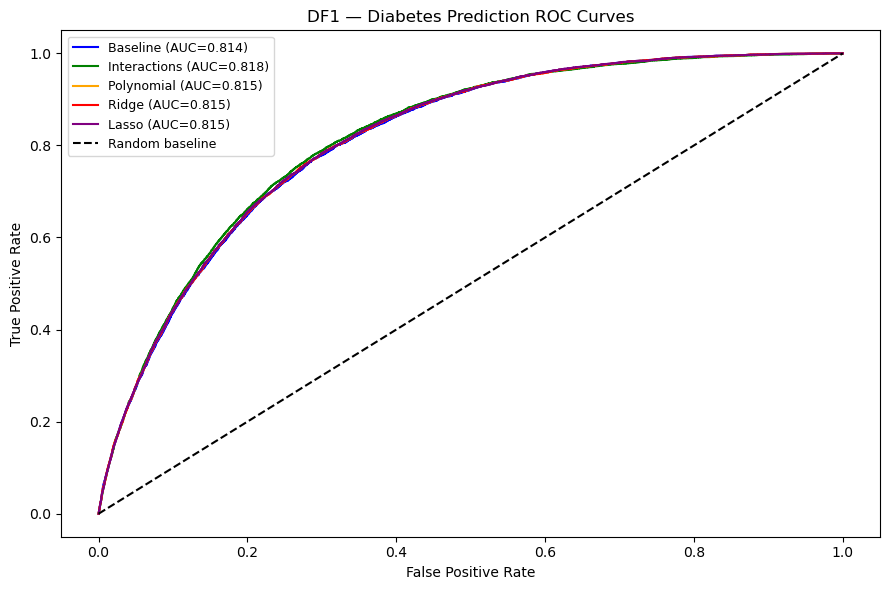

In [21]:
# Summarize AUC scores across all models
summary1 = pd.DataFrame({
    'Model': ['Baseline', 'Interactions', 'Polynomial', 'Ridge', 'Lasso'],
    'ROC-AUC': [auc1_base, auc1_inter, auc1_poly, auc1_ridge, auc1_lasso]
})
print('DF1 Model Comparison:')
print(summary1.to_string(index=False))

# ROC curve comparison
fig, ax = plt.subplots(figsize=(9, 6))
for label, prob, color in [
    ('Baseline',     prob1_base,  'blue'),
    ('Interactions', prob1_inter, 'green'),
    ('Polynomial',   prob1_poly,  'orange'),
    ('Ridge',        prob1_ridge, 'red'),
    ('Lasso',        prob1_lasso, 'purple'),
]:
    fpr, tpr, _ = roc_curve(y1_test, prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC={roc_auc_score(y1_test, prob):.3f})', color=color)
ax.plot([0,1],[0,1],'k--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('DF1 — Diabetes Prediction ROC Curves')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
# DATASET 2 — Diabetic Hospital Data
**Target:** `readmitted` — predicting whether a patient is readmitted within 30 days (1) or not (0).

**Continuous features:** age, time in hospital, lab procedures, medications, visits  
**Categorical features:** gender, race, drug dosage changes, diagnosis categories, admission type

In [22]:
print('Continuous features for df2:')
print(CONTINUOUS['df2'])
print(f'\nContinuous feature stats:')
print(df2[CONTINUOUS['df2']].describe().round(2))

cat_cols_df2 = [c for c in df2.columns
                if c not in CONTINUOUS['df2'] and c != 'readmitted']
print(f'\nCategorical/encoded features: {len(cat_cols_df2)} columns')

Continuous features for df2:
['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Continuous feature stats:
             age  time_in_hospital  num_lab_procedures  num_procedures  \
count  101766.00         101766.00           101766.00       101766.00   
mean       65.97              4.40               43.10            1.34   
std        15.94              2.99               19.67            1.71   
min         5.00              1.00                1.00            0.00   
25%        55.00              2.00               31.00            0.00   
50%        65.00              4.00               44.00            1.00   
75%        75.00              6.00               57.00            2.00   
max        95.00             14.00              132.00            6.00   

       num_medications  number_outpatient  number_emergency  number_inpatient  \
count        101766.00      

In [23]:
X2, y2 = prepare_Xy(df2, target='readmitted')

print(f'Dataset size: {X2.shape}')
print(f'Class balance (readmitted <30 days):\n{y2.value_counts(normalize=True).round(3)}')

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

X2_train_scaled, X2_test_scaled, _ = scale_features(
    X2_train, X2_test, CONTINUOUS['df2']
)
print(f'\nTrain: {X2_train_scaled.shape} | Test: {X2_test_scaled.shape}')

Dataset size: (298, 122)
Class balance (readmitted <30 days):
__target__
0    0.879
1    0.121
Name: proportion, dtype: float64

Train: (238, 122) | Test: (60, 122)


In [24]:
lr2 = LinearRegression()
lr2.fit(X2_train_scaled, y2_train)
prob2_base, auc2_base = evaluate(lr2, X2_test_scaled, y2_test, 'DF2 Baseline')

coef2 = pd.DataFrame({
    'Feature': X2_train_scaled.columns,
    'Coefficient': lr2.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print('\nTop 10 features by coefficient magnitude:')
print(coef2.head(10).to_string(index=False))


=== DF2 Baseline ===
              precision    recall  f1-score   support

           0       0.88      0.85      0.87        53
           1       0.11      0.14      0.12         7

    accuracy                           0.77        60
   macro avg       0.50      0.50      0.50        60
weighted avg       0.79      0.77      0.78        60

Confusion Matrix:
[[45  8]
 [ 6  1]]
ROC-AUC: 0.6011

Top 10 features by coefficient magnitude:
                    Feature   Coefficient
                tolbutamide -1.673112e+12
                 race_Other  1.261665e+12
                 race_Asian  1.261665e+12
       race_AfricanAmerican  1.261665e+12
              race_Hispanic  1.261665e+12
                   race_nan  1.261665e+12
             race_Caucasian  1.261665e+12
discharge_disposition_id_10 -8.625265e+11
discharge_disposition_id_11 -8.625265e+11
 discharge_disposition_id_6 -8.625265e+11


In [25]:
# df2 has many drug columns that may be correlated (patients on one drug
# are more likely on others). VIF will reveal this.
# We only run VIF on a subset of key features to keep it readable.

vif_cols2 = CONTINUOUS['df2'] + ['insulin', 'metformin', 'diabetesMed',
                                   'num_medications', 'change']
vif_cols2 = [c for c in vif_cols2 if c in X2_train_scaled.columns]

vif2 = compute_vif(X2_train_scaled[vif_cols2])
print('VIF scores for key DF2 features:')
print(vif2[vif2['Feature'] != 'const'].to_string(index=False))

high_vif2 = vif2[(vif2['VIF'] > 5) & (vif2['Feature'] != 'const')]['Feature'].tolist()
print(f'\nFeatures with VIF > 5: {high_vif2}')

VIF scores for key DF2 features:
           Feature      VIF
   num_medications      inf
   num_medications      inf
            change 2.418580
           insulin 2.016296
  number_emergency 1.788271
         metformin 1.652122
       diabetesMed 1.631278
  number_inpatient 1.553021
  number_diagnoses 1.552552
 number_outpatient 1.396614
  time_in_hospital 1.350165
num_lab_procedures 1.205988
               age 1.181607
    num_procedures 1.154158

Features with VIF > 5: ['num_medications', 'num_medications']


In [26]:
# Clinical rationale:
#   num_medications * time_in_hospital  — more meds + longer stay signals severity
#   number_inpatient * number_emergency — frequent inpatient + ER visits = high risk
#   insulin * num_medications           — insulin use + medication count reflects complexity
#   age * number_inpatient              — older patients with prior admissions at higher risk

interaction_pairs_2 = [
    ('num_medications', 'time_in_hospital'),
    ('number_inpatient', 'number_emergency'),
    ('insulin', 'num_medications'),
    ('age', 'number_inpatient')
]

X2_train_inter, X2_test_inter = add_interaction_terms(
    X2_train_scaled, X2_test_scaled, interaction_pairs_2
)

lr2_inter = LinearRegression()
lr2_inter.fit(X2_train_inter, y2_train)
prob2_inter, auc2_inter = evaluate(lr2_inter, X2_test_inter, y2_test, 'DF2 + Interactions')


=== DF2 + Interactions ===
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        53
           1       0.22      0.29      0.25         7

    accuracy                           0.80        60
   macro avg       0.56      0.58      0.57        60
weighted avg       0.82      0.80      0.81        60

Confusion Matrix:
[[46  7]
 [ 5  2]]
ROC-AUC: 0.6199


In [27]:
X2_train_poly, X2_test_poly, poly_names2 = add_polynomial_terms(
    X2_train_scaled, X2_test_scaled, CONTINUOUS['df2'], degree=2
)

print(f'Feature count: {X2_train_scaled.shape[1]} → {X2_train_poly.shape[1]}')

lr2_poly = LinearRegression()
lr2_poly.fit(X2_train_poly, y2_train)
prob2_poly, auc2_poly = evaluate(lr2_poly, X2_test_poly, y2_test, 'DF2 + Polynomial')

Feature count: 122 → 167

=== DF2 + Polynomial ===
              precision    recall  f1-score   support

           0       0.90      0.66      0.76        53
           1       0.14      0.43      0.21         7

    accuracy                           0.63        60
   macro avg       0.52      0.54      0.49        60
weighted avg       0.81      0.63      0.70        60

Confusion Matrix:
[[35 18]
 [ 4  3]]
ROC-AUC: 0.5256


In [28]:
ridge2 = Ridge(alpha=1.0)
ridge2.fit(X2_train_poly, y2_train)
prob2_ridge, auc2_ridge = evaluate(ridge2, X2_test_poly, y2_test, 'DF2 Ridge')

lasso2 = Lasso(alpha=0.001)
lasso2.fit(X2_train_poly, y2_train)
prob2_lasso, auc2_lasso = evaluate(lasso2, X2_test_poly, y2_test, 'DF2 Lasso')

print(f'\nLasso kept {(lasso2.coef_ != 0).sum()} features, zeroed {(lasso2.coef_ == 0).sum()}')


=== DF2 Ridge ===
              precision    recall  f1-score   support

           0       0.89      0.77      0.83        53
           1       0.14      0.29      0.19         7

    accuracy                           0.72        60
   macro avg       0.52      0.53      0.51        60
weighted avg       0.80      0.72      0.75        60

Confusion Matrix:
[[41 12]
 [ 5  2]]
ROC-AUC: 0.6442

=== DF2 Lasso ===
              precision    recall  f1-score   support

           0       0.90      0.83      0.86        53
           1       0.18      0.29      0.22         7

    accuracy                           0.77        60
   macro avg       0.54      0.56      0.54        60
weighted avg       0.81      0.77      0.79        60

Confusion Matrix:
[[44  9]
 [ 5  2]]
ROC-AUC: 0.5633

Lasso kept 79 features, zeroed 88


DF2 Model Comparison:
       Model  ROC-AUC
    Baseline 0.601078
Interactions 0.619946
  Polynomial 0.525606
       Ridge 0.644205
       Lasso 0.563342


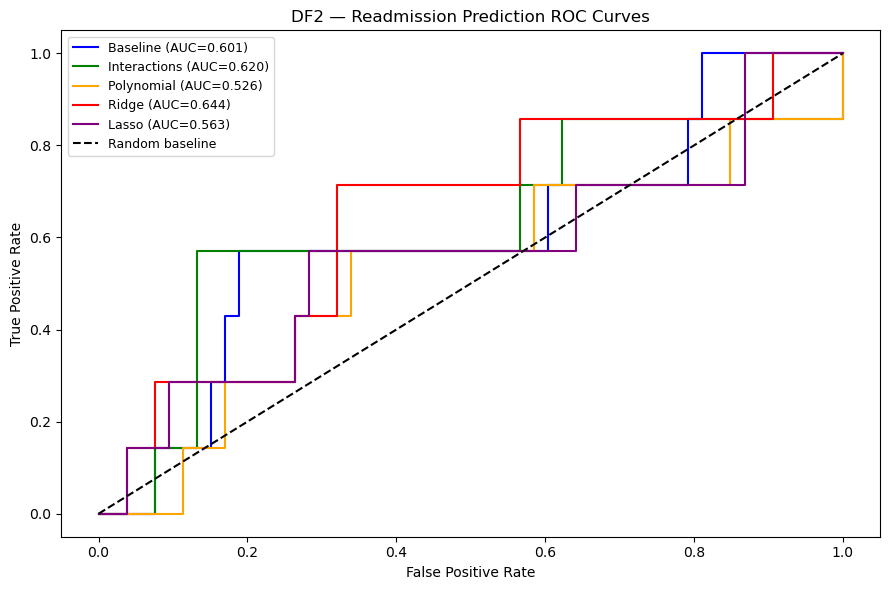

In [29]:
summary2 = pd.DataFrame({
    'Model': ['Baseline', 'Interactions', 'Polynomial', 'Ridge', 'Lasso'],
    'ROC-AUC': [auc2_base, auc2_inter, auc2_poly, auc2_ridge, auc2_lasso]
})
print('DF2 Model Comparison:')
print(summary2.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
for label, prob, color in [
    ('Baseline',     prob2_base,  'blue'),
    ('Interactions', prob2_inter, 'green'),
    ('Polynomial',   prob2_poly,  'orange'),
    ('Ridge',        prob2_ridge, 'red'),
    ('Lasso',        prob2_lasso, 'purple'),
]:
    fpr, tpr, _ = roc_curve(y2_test, prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC={roc_auc_score(y2_test, prob):.3f})', color=color)
ax.plot([0,1],[0,1],'k--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('DF2 — Readmission Prediction ROC Curves')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
# DATASET 3 — Stroke Data
**Target:** `stroke` — predicting whether a patient had a stroke (1) or not (0).

**Continuous features:** age, average glucose level, BMI  
**Categorical features:** gender, hypertension, heart disease, marital status, work type, residence, smoking status

> **Note on class imbalance:** Stroke is ~5% of cases. Accuracy alone is misleading — a model that always predicts 0 gets 95% accuracy. Focus on ROC-AUC and recall for the stroke class.

In [30]:
print('Continuous features for df3:')
print(CONTINUOUS['df3'])
print(f'\nContinuous feature stats:')
print(df3[CONTINUOUS['df3']].describe().round(2))

print(f'\nClass balance:')
print(df3['stroke'].value_counts(normalize=True).round(3))

Continuous features for df3:
['age', 'avg_glucose_level', 'bmi']

Continuous feature stats:
           age  avg_glucose_level      bmi
count  5109.00            5109.00  5109.00
mean     43.23             106.14    28.86
std      22.61              45.29     7.70
min       0.08              55.12    10.30
25%      25.00              77.24    23.80
50%      45.00              91.88    28.10
75%      61.00             114.09    32.80
max      82.00             271.74    97.60

Class balance:
stroke
0    0.951
1    0.049
Name: proportion, dtype: float64


In [31]:
X3, y3 = prepare_Xy(df3, target='stroke')

print(f'Dataset size: {X3.shape}')

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

X3_train_scaled, X3_test_scaled, _ = scale_features(
    X3_train, X3_test, CONTINUOUS['df3']
)
print(f'Train: {X3_train_scaled.shape} | Test: {X3_test_scaled.shape}')

Dataset size: (5109, 17)
Train: (4087, 17) | Test: (1022, 17)


In [32]:
lr3 = LinearRegression()
lr3.fit(X3_train_scaled, y3_train)
prob3_base, auc3_base = evaluate(lr3, X3_test_scaled, y3_test, 'DF3 Baseline')

coef3 = pd.DataFrame({
    'Feature': X3_train_scaled.columns,
    'Coefficient': lr3.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print('\nTop 10 features by coefficient magnitude:')
print(coef3.head(10).to_string(index=False))


=== DF3 Baseline ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Confusion Matrix:
[[972   0]
 [ 50   0]]
ROC-AUC: 0.8240

Top 10 features by coefficient magnitude:
                       Feature   Coefficient
   smoking_status_never smoked -4.727521e+11
         smoking_status_smokes -4.727521e+11
        smoking_status_Unknown -4.727521e+11
smoking_status_formerly smoked -4.727521e+11
       work_type_Self-employed -3.674212e+09
            work_type_Govt_job -3.674212e+09
             work_type_Private -3.674212e+09
        work_type_Never_worked -3.674212e+09
            work_type_children -3.674212e+09
                           age  6.954079e-02


In [34]:
# Convert all columns to float before VIF (get_dummies produces bool dtype in newer pandas)
X3_train_scaled = X3_train_scaled.astype(float)
X3_test_scaled = X3_test_scaled.astype(float)

vif3 = compute_vif(X3_train_scaled)
print('VIF scores for DF3 features:')
print(vif3[vif3['Feature'] != 'const'].to_string(index=False))

high_vif3 = vif3[(vif3['VIF'] > 5) & (vif3['Feature'] != 'const')]['Feature'].tolist()
print(f'\nFeatures with VIF > 5: {high_vif3}')

VIF scores for DF3 features:
                       Feature      VIF
            work_type_Govt_job      inf
        work_type_Never_worked      inf
   smoking_status_never smoked      inf
smoking_status_formerly smoked      inf
        smoking_status_Unknown      inf
            work_type_children      inf
       work_type_Self-employed      inf
             work_type_Private      inf
         smoking_status_smokes      inf
                           age 2.898163
                  ever_married 2.012547
                           bmi 1.301177
                 heart_disease 1.122955
                  hypertension 1.113266
             avg_glucose_level 1.103881
                        gender 1.028696
                Residence_type 1.002904

Features with VIF > 5: ['work_type_Govt_job', 'work_type_Never_worked', 'smoking_status_never smoked', 'smoking_status_formerly smoked', 'smoking_status_Unknown', 'work_type_children', 'work_type_Self-employed', 'work_type_Private', 'smoking_status_s

In [35]:
# In stroke data: age correlates with hypertension, heart disease,
# glucose level, and BMI — all of which also correlate with each other.
# VIF will show whether this creates unstable coefficients.

vif3 = compute_vif(X3_train_scaled)
print('VIF scores for DF3 features:')
print(vif3[vif3['Feature'] != 'const'].to_string(index=False))

high_vif3 = vif3[(vif3['VIF'] > 5) & (vif3['Feature'] != 'const')]['Feature'].tolist()
print(f'\nFeatures with VIF > 5: {high_vif3}')

VIF scores for DF3 features:
                       Feature      VIF
            work_type_Govt_job      inf
        work_type_Never_worked      inf
   smoking_status_never smoked      inf
smoking_status_formerly smoked      inf
        smoking_status_Unknown      inf
            work_type_children      inf
       work_type_Self-employed      inf
             work_type_Private      inf
         smoking_status_smokes      inf
                           age 2.898163
                  ever_married 2.012547
                           bmi 1.301177
                 heart_disease 1.122955
                  hypertension 1.113266
             avg_glucose_level 1.103881
                        gender 1.028696
                Residence_type 1.002904

Features with VIF > 5: ['work_type_Govt_job', 'work_type_Never_worked', 'smoking_status_never smoked', 'smoking_status_formerly smoked', 'smoking_status_Unknown', 'work_type_children', 'work_type_Self-employed', 'work_type_Private', 'smoking_status_s

In [36]:
# Clinical rationale:
#   age * avg_glucose_level  — high glucose risk amplifies sharply with age
#   hypertension * heart_disease — two major compounding stroke risk factors
#   age * hypertension       — hypertension effects increase with age
#   bmi * avg_glucose_level  — metabolic syndrome proxy

interaction_pairs_3 = [
    ('age', 'avg_glucose_level'),
    ('hypertension', 'heart_disease'),
    ('age', 'hypertension'),
    ('bmi', 'avg_glucose_level')
]

X3_train_inter, X3_test_inter = add_interaction_terms(
    X3_train_scaled, X3_test_scaled, interaction_pairs_3
)

lr3_inter = LinearRegression()
lr3_inter.fit(X3_train_inter, y3_train)
prob3_inter, auc3_inter = evaluate(lr3_inter, X3_test_inter, y3_test, 'DF3 + Interactions')


=== DF3 + Interactions ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Confusion Matrix:
[[972   0]
 [ 50   0]]
ROC-AUC: 0.8314


In [37]:
X3_train_poly, X3_test_poly, poly_names3 = add_polynomial_terms(
    X3_train_scaled, X3_test_scaled, CONTINUOUS['df3'], degree=2
)

print(f'Polynomial features: {list(poly_names3)}')
print(f'Feature count: {X3_train_scaled.shape[1]} → {X3_train_poly.shape[1]}')

lr3_poly = LinearRegression()
lr3_poly.fit(X3_train_poly, y3_train)
prob3_poly, auc3_poly = evaluate(lr3_poly, X3_test_poly, y3_test, 'DF3 + Polynomial')

Polynomial features: ['age', 'avg_glucose_level', 'bmi', 'age^2', 'age avg_glucose_level', 'age bmi', 'avg_glucose_level^2', 'avg_glucose_level bmi', 'bmi^2']
Feature count: 17 → 23

=== DF3 + Polynomial ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Confusion Matrix:
[[972   0]
 [ 50   0]]
ROC-AUC: 0.8220


In [38]:
ridge3 = Ridge(alpha=1.0)
ridge3.fit(X3_train_poly, y3_train)
prob3_ridge, auc3_ridge = evaluate(ridge3, X3_test_poly, y3_test, 'DF3 Ridge')

lasso3 = Lasso(alpha=0.001)
lasso3.fit(X3_train_poly, y3_train)
prob3_lasso, auc3_lasso = evaluate(lasso3, X3_test_poly, y3_test, 'DF3 Lasso')

print(f'\nLasso kept {(lasso3.coef_ != 0).sum()} features, zeroed {(lasso3.coef_ == 0).sum()}')


=== DF3 Ridge ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Confusion Matrix:
[[972   0]
 [ 50   0]]
ROC-AUC: 0.8232

=== DF3 Lasso ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Confusion Matrix:
[[972   0]
 [ 50   0]]
ROC-AUC: 0.8315

Lasso kept 15 features, zeroed 8


DF3 Model Comparison:
       Model  ROC-AUC
    Baseline 0.824012
Interactions 0.831440
  Polynomial 0.822006
       Ridge 0.823210
       Lasso 0.831523


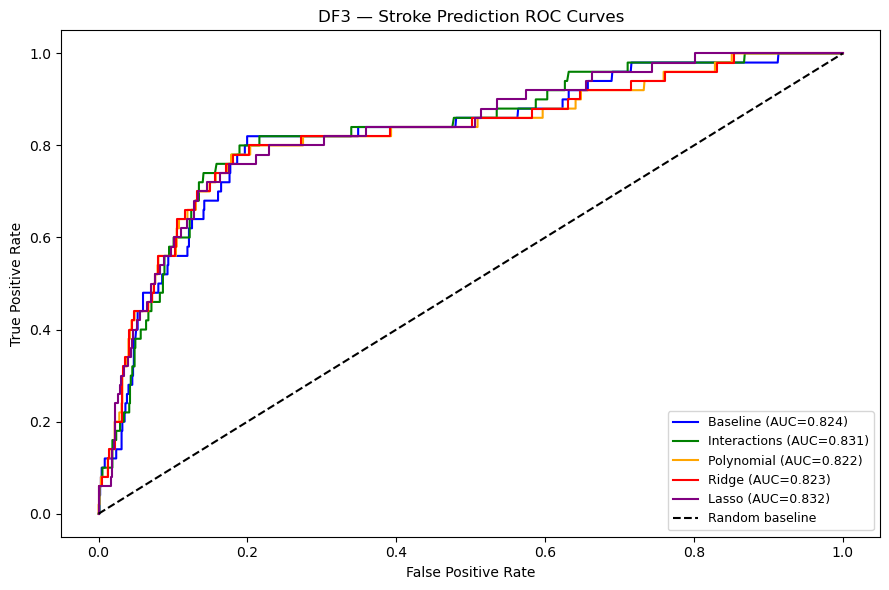

In [39]:
summary3 = pd.DataFrame({
    'Model': ['Baseline', 'Interactions', 'Polynomial', 'Ridge', 'Lasso'],
    'ROC-AUC': [auc3_base, auc3_inter, auc3_poly, auc3_ridge, auc3_lasso]
})
print('DF3 Model Comparison:')
print(summary3.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
for label, prob, color in [
    ('Baseline',     prob3_base,  'blue'),
    ('Interactions', prob3_inter, 'green'),
    ('Polynomial',   prob3_poly,  'orange'),
    ('Ridge',        prob3_ridge, 'red'),
    ('Lasso',        prob3_lasso, 'purple'),
]:
    fpr, tpr, _ = roc_curve(y3_test, prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC={roc_auc_score(y3_test, prob):.3f})', color=color)
ax.plot([0,1],[0,1],'k--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('DF3 — Stroke Prediction ROC Curves')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [40]:
summary_all = pd.DataFrame({
    'Model':        ['Baseline', 'Interactions', 'Polynomial', 'Ridge', 'Lasso'],
    'DF1 (Diabetes)':   [auc1_base, auc1_inter, auc1_poly, auc1_ridge, auc1_lasso],
    'DF2 (Readmission)': [auc2_base, auc2_inter, auc2_poly, auc2_ridge, auc2_lasso],
    'DF3 (Stroke)':     [auc3_base, auc3_inter, auc3_poly, auc3_ridge, auc3_lasso],
})
summary_all = summary_all.set_index('Model').round(4)
print('ROC-AUC Scores Across All Datasets:')
print(summary_all.to_string())

ROC-AUC Scores Across All Datasets:
              DF1 (Diabetes)  DF2 (Readmission)  DF3 (Stroke)
Model                                                        
Baseline              0.8139             0.6011        0.8240
Interactions          0.8176             0.6199        0.8314
Polynomial            0.8151             0.5256        0.8220
Ridge                 0.8151             0.6442        0.8232
Lasso                 0.8155             0.5633        0.8315


In [41]:
from sklearn.linear_model import ElasticNet

# Elastic Net (L1 + L2 combined):
# Combines Ridge and Lasso penalties using two parameters:
#   alpha   — overall penalty strength (same as Ridge/Lasso)
#   l1_ratio — mix between L1 and L2:
#              0 = pure Ridge, 1 = pure Lasso, 0.5 = equal mix
#
# Advantages over Ridge or Lasso alone:
#   - Like Lasso: can zero out irrelevant features
#   - Like Ridge: stable when features are correlated (multicollinearity)
#   - Best of both when you have many features AND some correlation between them

enet1 = ElasticNet(alpha=0.001, l1_ratio=0.5)
enet1.fit(X1_train_poly, y1_train)
prob1_enet, auc1_enet = evaluate(enet1, X1_test_poly, y1_test, 'DF1 Elastic Net')

n_kept  = (enet1.coef_ != 0).sum()
n_zeroed = (enet1.coef_ == 0).sum()
print(f'\nElastic Net kept {n_kept} features, zeroed out {n_zeroed}')


=== DF1 Elastic Net ===
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     47259
         1.0       0.61      0.05      0.09      7918

    accuracy                           0.86     55177
   macro avg       0.73      0.52      0.51     55177
weighted avg       0.83      0.86      0.80     55177

Confusion Matrix:
[[47011   248]
 [ 7535   383]]
ROC-AUC: 0.8154

Elastic Net kept 22 features, zeroed out 1


In [45]:
enet2 = ElasticNet(alpha=0.001, l1_ratio=0.5)
enet2.fit(X2_train_poly, y2_train)
prob2_enet, auc2_enet = evaluate(enet2, X2_test_poly, y2_test, 'DF2 Elastic Net')

n_kept  = (enet2.coef_ != 0).sum()
n_zeroed = (enet2.coef_ == 0).sum()
print(f'\nElastic Net kept {n_kept} features, zeroed out {n_zeroed}')


=== DF2 Elastic Net ===
              precision    recall  f1-score   support

           0       0.89      0.79      0.84        53
           1       0.15      0.29      0.20         7

    accuracy                           0.73        60
   macro avg       0.52      0.54      0.52        60
weighted avg       0.81      0.73      0.77        60

Confusion Matrix:
[[42 11]
 [ 5  2]]
ROC-AUC: 0.5606

Elastic Net kept 95 features, zeroed out 72


In [47]:
enet3 = ElasticNet(alpha=0.001, l1_ratio=0.5)
enet3.fit(X3_train_poly, y3_train)
prob3_enet, auc3_enet = evaluate(enet3, X3_test_poly, y3_test, 'DF3 Elastic Net')

n_kept  = (enet3.coef_ != 0).sum()
n_zeroed = (enet3.coef_ == 0).sum()
print(f'\nElastic Net kept {n_kept} features, zeroed out {n_zeroed}')


=== DF3 Elastic Net ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Confusion Matrix:
[[972   0]
 [ 50   0]]
ROC-AUC: 0.8278

Elastic Net kept 16 features, zeroed out 7


In [42]:
# Updated summary table
summary1 = pd.DataFrame({
    'Model':   ['Baseline', 'Interactions', 'Polynomial', 'Ridge', 'Lasso', 'Elastic Net'],
    'ROC-AUC': [auc1_base, auc1_inter, auc1_poly, auc1_ridge, auc1_lasso, auc1_enet]
})
print(summary1.to_string(index=False))

# Updated ROC plot — add this line inside the plot loop
# ('Elastic Net', prob1_enet, 'brown'),

       Model  ROC-AUC
    Baseline 0.813903
Interactions 0.817639
  Polynomial 0.815075
       Ridge 0.815075
       Lasso 0.815460
 Elastic Net 0.815361


In [48]:
# Updated summary table
summary2 = pd.DataFrame({
    'Model':   ['Baseline', 'Interactions', 'Polynomial', 'Ridge', 'Lasso', 'Elastic Net'],
    'ROC-AUC': [auc2_base, auc2_inter, auc2_poly, auc2_ridge, auc2_lasso, auc2_enet]
})
print(summary2.to_string(index=False))

# Updated ROC plot — add this line inside the plot loop
# ('Elastic Net', prob1_enet, 'brown'),

       Model  ROC-AUC
    Baseline 0.601078
Interactions 0.619946
  Polynomial 0.525606
       Ridge 0.644205
       Lasso 0.563342
 Elastic Net 0.560647


In [49]:
# Updated summary table
summary3 = pd.DataFrame({
    'Model':   ['Baseline', 'Interactions', 'Polynomial', 'Ridge', 'Lasso', 'Elastic Net'],
    'ROC-AUC': [auc3_base, auc3_inter, auc3_poly, auc3_ridge, auc3_lasso, auc3_enet]
})
print(summary3.to_string(index=False))

# Updated ROC plot — add this line inside the plot loop
# ('Elastic Net', prob1_enet, 'brown'),

       Model  ROC-AUC
    Baseline 0.824012
Interactions 0.831440
  Polynomial 0.822006
       Ridge 0.823210
       Lasso 0.831523
 Elastic Net 0.827798


In [50]:
summary_all = pd.DataFrame({
    'Model':             ['Baseline', 'Interactions', 'Polynomial', 'Ridge', 'Lasso', 'Elastic Net'],
    'DF1 (Diabetes)':    [auc1_base, auc1_inter, auc1_poly, auc1_ridge, auc1_lasso, auc1_enet],
    'DF2 (Readmission)': [auc2_base, auc2_inter, auc2_poly, auc2_ridge, auc2_lasso, auc2_enet],
    'DF3 (Stroke)':      [auc3_base, auc3_inter, auc3_poly, auc3_ridge, auc3_lasso, auc3_enet],
})

In [51]:
print(summary_all)

          Model  DF1 (Diabetes)  DF2 (Readmission)  DF3 (Stroke)
0      Baseline        0.813903           0.601078      0.824012
1  Interactions        0.817639           0.619946      0.831440
2    Polynomial        0.815075           0.525606      0.822006
3         Ridge        0.815075           0.644205      0.823210
4         Lasso        0.815460           0.563342      0.831523
5   Elastic Net        0.815361           0.560647      0.827798
